# Part 1 - Job Shop Scheduling (working notebook)

**Not part of the submission.** This notebook exists to make the scheduling logic visible so you can write the report.

The core of every question is one formula, applied to each action in order:

```
start  = max( operation ready time , machine free time )
finish = start + processing time
```

- **ready time** = the job's own constraints (arrival for a first op; predecessor's finish for a second op)
- **machine free time** = the resource constraint (a machine runs one op at a time)

Whichever is *later* decides when the action actually starts.

Run the cells top to bottom (Shift+Enter).

## Step 1 - Problem data

The 3 jobs / 2 machines table from the assignment, encoded as Python.

In [41]:
# When each job arrives (its first operation cannot start before this time).
ARRIVAL = {"J1": 0, "J2": 10, "J3": 20}

# op_name : (job, machine, proc_time, is_first_op)
OPS = {
    "O11": ("J1", "M1", 50, True),   # J1's first op
    "O12": ("J1", "M2", 25, False),  # J1's second op (needs O11 done first)
    "O21": ("J2", "M2", 30, True),   # J2's first op
    "O22": ("J2", "M1", 35, False),  # J2's second op (needs O21 done first)
    "O31": ("J3", "M1", 40, True),   # J3's first op
    "O32": ("J3", "M2", 20, False),  # J3's second op (needs O31 done first)
}

# First operation of each job, so a second op can find when its predecessor finished.
FIRST_OP = {"J1": "O11", "J2": "O21", "J3": "O31"}

print("Loaded", len(OPS), "operations across", len(ARRIVAL), "jobs.")

Loaded 6 operations across 3 jobs.


## Step 2 - The scheduler

Walk the action sequence in order and time each action with `start = max(ready, machine free)`.
Returns one result dict per action so we can print the full reasoning afterwards.

In [42]:
def schedule(sequence):
    """Given an ordered list of operations, compute start/finish for each."""
    machine_free = {"M1": 0, "M2": 0}  # earliest time each machine is idle
    op_finish = {}                     # op_name -> its finish time (precedence)
    results = []

    for op in sequence:
        job, machine, proc, is_first = OPS[op]

        # Step 1: operation ready time
        # First op  -> ready at the job's arrival time.
        # Second op -> ready when the job's first op FINISHED.
        if is_first:
            ready = ARRIVAL[job]
            ready_reason = f"{job} arrives at {ready}"
        else:
            predecessor = FIRST_OP[job]
            ready = op_finish[predecessor]
            ready_reason = f"{predecessor} finishes at {ready} (precedence)"

        # Step 2: machine free time
        free = machine_free[machine]

        # Step 3: start = max(ready, machine free)
        start = max(ready, free)

        # Which constraint actually decided the start time? (useful for the report)
        if ready > free:
            bound = "waiting on the operation (ready time)"
        elif free > ready:
            bound = f"waiting on the machine ({machine} busy until {free})"
        else:
            bound = "both became available at the same moment"

        # Step 4: finish = start + processing time
        finish = start + proc

        # Step 5: update state for later actions
        machine_free[machine] = finish  # this machine is now busy until finish
        op_finish[op] = finish          # remember finish for any successor op

        results.append({
            "op": op, "machine": machine, "proc": proc,
            "ready": ready, "ready_reason": ready_reason,
            "free": free, "start": start, "finish": finish, "bound": bound,
        })

    return results

print("schedule() defined.")

schedule() defined.


## Step 3 - Pretty-print the reasoning

Prints each action's ready time, machine free time, the `max`, and which constraint won -
plus a summary of t1..t6 and the non-decreasing consistency check.

In [43]:
def report(sequence):
    results = schedule(sequence)

    print("=" * 70)
    print("Earliest start times")
    print("Sequence:", "  ->  ".join(sequence))
    print("=" * 70)

    for i, r in enumerate(results, start=1):
        print(f"\nAction {i}:  Process({r['op']}, {r['machine']}, t{i})")
        print(f"  ready time   = {r['ready']:>3}   ({r['ready_reason']})")
        print(f"  {r['machine']} free at   = {r['free']:>3}")
        print(f"  start  t{i}    = max({r['ready']}, {r['free']}) = {r['start']:>3}"
              f"   <- {r['bound']}")
        print(f"  finish       = {r['start']} + {r['proc']} = {r['finish']:>3}")

    # Summary line of t1..tN, in the assignment's notation.
    print("\n" + "-" * 70)
    starts = [r["start"] for r in results]
    print("Summary:  " + ",  ".join(
        f"t{i}={s}" for i, s in enumerate(starts, start=1)))

    # The sequence is sorted by start time, so starts must be non-decreasing.
    ok = all(a <= b for a, b in zip(starts, starts[1:]))
    print(f"Non-decreasing check (t1 <= ... <= tN): {'PASS' if ok else 'FAIL'}")
    print("-" * 70)

    return results

print("report() defined.")

report() defined.


## Step 4 - Q1: run the given FCFS sequence

`O11 -> O21 -> O31 -> O12 -> O22 -> O32`

In [44]:
fcfs_sequence = ["O11", "O21", "O31", "O12", "O22", "O32"]
results = report(fcfs_sequence)

Earliest start times
Sequence: O11  ->  O21  ->  O31  ->  O12  ->  O22  ->  O32

Action 1:  Process(O11, M1, t1)
  ready time   =   0   (J1 arrives at 0)
  M1 free at   =   0
  start  t1    = max(0, 0) =   0   <- both became available at the same moment
  finish       = 0 + 50 =  50

Action 2:  Process(O21, M2, t2)
  ready time   =  10   (J2 arrives at 10)
  M2 free at   =   0
  start  t2    = max(10, 0) =  10   <- waiting on the operation (ready time)
  finish       = 10 + 30 =  40

Action 3:  Process(O31, M1, t3)
  ready time   =  20   (J3 arrives at 20)
  M1 free at   =  50
  start  t3    = max(20, 50) =  50   <- waiting on the machine (M1 busy until 50)
  finish       = 50 + 40 =  90

Action 4:  Process(O12, M2, t4)
  ready time   =  50   (O11 finishes at 50 (precedence))
  M2 free at   =  40
  start  t4    = max(50, 40) =  50   <- waiting on the operation (ready time)
  finish       = 50 + 25 =  75

Action 5:  Process(O22, M1, t5)
  ready time   =  40   (O21 finishes at 40 (preced

## Step 4b - Q1 table: operation ready time vs machine idle time

A compact view of the `start = max(ready, machine free)` rule. For each operation the table
shows, side by side, the **earliest ready time of the operation** (its job constraint) and the
**earliest idle time of the machine** it runs on (the resource constraint). The start time is
the larger of the two, and the `binds` column names which constraint decided it.

Needs Step 4 (`results`) to have run first.

In [45]:
# Q1 table: for each operation, the earliest ready time of the operation (its job
# constraint) next to the earliest idle time of the machine it runs on (the resource
# constraint). start = max(the two); 'binds' names whichever one decided the start.
rows = []
for r in results:
    if r["ready"] > r["free"]:
        binds = "operation (ready time)"
    elif r["free"] > r["ready"]:
        binds = "machine (idle time)"
    else:
        binds = "tie"
    rows.append({
        "operation": r["op"],
        "machine": r["machine"],
        "op ready time": r["ready"],
        "machine idle time": r["free"],
        "start = max": r["start"],
        "binds": binds,
    })

try:
    import pandas as pd
    table = pd.DataFrame(rows).set_index("operation")
    display(table)
except ImportError:
    # plain-text fallback if pandas is unavailable
    hdr = f"{'op':<5}{'machine':<9}{'op ready':>9}{'mach idle':>11}{'start':>7}  binds"
    print(hdr)
    print("-" * len(hdr))
    for row in rows:
        print(f"{row['operation']:<5}{row['machine']:<9}{row['op ready time']:>9}"
              f"{row['machine idle time']:>11}{row['start = max']:>7}  {row['binds']}")

,machine,op ready time,machine idle time,start = max,binds
operation,,,,,
O11,M1,0,0,0,tie
O21,M2,10,0,10,operation (ready time)
O31,M1,20,50,50,machine (idle time)
O12,M2,50,40,50,operation (ready time)
O22,M1,40,90,90,machine (idle time)
O32,M2,90,75,90,operation (ready time)


## Step 5 - Gantt chart

Draws the schedule from `results` (run Step 4 first). Each bar is one operation,
coloured by job; the dashed red line marks the makespan. Saves `gantt_q1.png` for the report.

Reading it: M1 runs back-to-back (it is the bottleneck), while M2 has idle gaps where it waits on precedence.

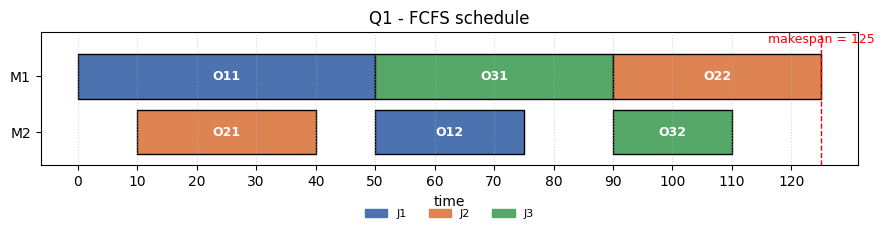

makespan = 125 -> saved gantt_q1.png


In [46]:
import matplotlib.pyplot as plt

def gantt(results, title="Gantt chart", save_as=None, log=None):
    """Draw a Gantt chart of `results`. If a decision `log` is passed (e.g. from
    schedule_spt), a small caption under each bar shows the decision order and
    whether it was forced ('only ready') or an SPT pick ('SPT a<b' = chosen proc
    a beat the next-shortest competitor b)."""
    machines = ["M1", "M2"]                       # row order (top row first)
    row_of = {m: i for i, m in enumerate(machines)}
    jobs = ["J1", "J2", "J3"]                     # one colour per job
    colours = {"J1": "#4C72B0", "J2": "#DD8452", "J3": "#55A868"}

    # per-operation decision note (only when a log is supplied)
    notes = {}
    if log:
        for n, d in enumerate(log, 1):
            c = d["candidates"]                    # sorted ascending by proc time
            notes[d["chosen"]] = (f"[{n}] SPT {c[0][1]}<{c[1][1]}"
                                  if len(c) > 1 else f"[{n}] only ready")

    bar_h = 0.6 if log else 0.8                    # thinner bars leave room for captions
    fig, ax = plt.subplots(figsize=(9, 3.4 if log else 2.6))
    for r in results:
        job = OPS[r["op"]][0]
        y = row_of[r["machine"]]
        ax.broken_barh([(r["start"], r["proc"])], (y - bar_h / 2, bar_h),
                       facecolors=colours[job], edgecolor="black")
        ax.text(r["start"] + r["proc"] / 2, y, r["op"], ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
        if r["op"] in notes:                        # decision caption under the bar
            ax.text(r["start"] + r["proc"] / 2, y + bar_h / 2 + 0.05, notes[r["op"]],
                    ha="center", va="top", fontsize=7, color="dimgray")

    makespan = max(r["finish"] for r in results)
    ax.set_yticks(range(len(machines)))
    ax.set_yticklabels(machines)
    ax.set_ylim(-0.8, 1.9 if log else 1.6)
    ax.invert_yaxis()                            # M1 on top
    ax.set_xlabel("time")
    ax.set_xticks(range(0, makespan + 1, 10))
    ax.set_title(title)
    ax.axvline(makespan, color="red", linestyle="--", linewidth=1)
    ax.text(makespan, -0.6, f"makespan = {makespan}", color="red", ha="center", fontsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    handles = [plt.Rectangle((0, 0), 1, 1, color=colours[j]) for j in jobs]
    ax.legend(handles, jobs, loc="upper center",
              bbox_to_anchor=(0.5, -0.32 if log else -0.25), ncol=3, fontsize=8, frameon=False)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=150, bbox_inches="tight")
    return fig, makespan

fig, makespan = gantt(results, title="Q1 - FCFS schedule", save_as="gantt_q1.png")
plt.show()
print("makespan =", makespan, "-> saved gantt_q1.png")

## Step 6 - Q2: completion time of each job + makespan

- **Completion time of a job** `C(Jj)` = finish time of its **last** operation (its second op, Oj2).
- **Makespan** = `max(C(J1), C(J2), C(J3))` = the time everything is finished.

Reads straight off the `finish` values already computed in `results`.

In [47]:
def completion_times(results):
    """Completion time of a job = finish time of its LAST operation.
    Returns (completion_dict, last_op_dict)."""
    comp, last = {}, {}
    for r in results:
        job = OPS[r["op"]][0]
        if r["finish"] >= comp.get(job, -1):  # keep the latest-finishing op per job
            comp[job] = r["finish"]
            last[job] = r["op"]
    return comp, last

comp, last = completion_times(results)

print("Completion time of each job = finish time of its last operation:\n")
for job in sorted(comp):
    print(f"  C({job}) = {comp[job]:>3}   (last operation: {last[job]})")

makespan = max(comp.values())
worst = max(comp, key=comp.get)
print(f"\nMakespan = max({', '.join(str(comp[j]) for j in sorted(comp))}) = {makespan}")
print(f"         = C({worst})  -> job {worst} is the last to finish")

# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("REPORT REMINDER (Q2) - come back to this:")
print(f"  Makespan ({makespan}) = C({worst}). {worst} finishes last NOT because it")
print("  arrived last (J3 did), but because its final op O22 had to wait for")
print("  M1 (busy until 90). => the bottleneck MACHINE, not the arrival order,")
print("  drives the makespan. Worth a sentence in the report.")
print("=" * 70)

Completion time of each job = finish time of its last operation:

  C(J1) =  75   (last operation: O12)
  C(J2) = 125   (last operation: O22)
  C(J3) = 110   (last operation: O32)

Makespan = max(75, 125, 110) = 125
         = C(J2)  -> job J2 is the last to finish

REPORT REMINDER (Q2) - come back to this:
  Makespan (125) = C(J2). J2 finishes last NOT because it
  arrived last (J3 did), but because its final op O22 had to wait for
  M1 (busy until 90). => the bottleneck MACHINE, not the arrival order,
  drives the makespan. Worth a sentence in the report.


## Step 7 - Q3: build the schedule with the SPT rule

Unlike Q1, the action order is **not given** - we build it. Simulate forward in time; whenever a
machine is free and one or more of its operations are ready, start the ready operation with the
**shortest processing time** (SPT).

The decision log below makes the rule visible. The only *real* SPT choice in this problem is at
**t=50 on M1**, where O22 (proc 35) and O31 (proc 40) are both ready - SPT takes the shorter O22.
That single choice is what makes SPT differ from FCFS (Q1 took O31 first because it had been
waiting longer).

In [48]:
def schedule_spt():
    """Non-delay schedule generation with the SPT dispatching rule.
    Never leave a machine idle when an op is ready; when several ready ops
    compete for the same machine, take the one with the shortest proc time."""
    machine_free = {"M1": 0, "M2": 0}
    op_finish = {}
    results, log = [], []

    def ready_time(op):
        job, machine, proc, is_first = OPS[op]
        if is_first:
            return ARRIVAL[job]
        return op_finish.get(FIRST_OP[job])  # None if predecessor not finished yet

    remaining = set(OPS)
    while remaining:
        # earliest possible start for every currently-schedulable op
        est = {}
        for op in remaining:
            rt = ready_time(op)
            if rt is None:                       # predecessor not done -> skip for now
                continue
            est[op] = max(rt, machine_free[OPS[op][1]])

        t_star = min(est.values())                                        # earliest a machine can work
        m_star = min(OPS[op][1] for op, e in est.items() if e == t_star)  # which machine
        conflict = [op for op, e in est.items() if e == t_star and OPS[op][1] == m_star]

        chosen = min(conflict, key=lambda op: OPS[op][2])                 # SPT: shortest proc wins

        machine, proc = OPS[chosen][1], OPS[chosen][2]
        start, finish = t_star, t_star + proc
        machine_free[machine] = finish
        op_finish[chosen] = finish
        remaining.discard(chosen)

        results.append({"op": chosen, "machine": machine, "proc": proc,
                        "start": start, "finish": finish})
        log.append({"time": t_star, "machine": m_star,
                    "candidates": sorted(((op, OPS[op][2]) for op in conflict), key=lambda x: x[1]),
                    "chosen": chosen, "start": start, "finish": finish})

    results.sort(key=lambda r: r["start"])
    return results, log


def report_spt(results, log):
    print("=" * 70)
    print("Q3 - Building the schedule with the SPT rule")
    print("=" * 70)
    for i, d in enumerate(log, 1):
        cand = ", ".join(f"{op}(proc={p})" for op, p in d["candidates"])
        note = "SPT pick - shortest wins" if len(d["candidates"]) > 1 else "only ready op"
        print(f"\nDecision {i}: t={d['time']}, {d['machine']} free")
        print(f"  ready & competing for {d['machine']}: {cand}")
        print(f"  -> choose {d['chosen']} ({note}); runs {d['start']}-{d['finish']}")
    print("\n" + "-" * 70)
    seq = " -> ".join(f"Process({r['op']}, {r['machine']}, {r['start']})" for r in results)
    print("SPT schedule (sorted by start time):\n ", seq)
    starts = [r["start"] for r in results]
    ok = all(a <= b for a, b in zip(starts, starts[1:]))
    print(f"Non-decreasing check: {'PASS' if ok else 'FAIL'}")
    print("-" * 70)


spt_results, spt_log = schedule_spt()
report_spt(spt_results, spt_log)

Q3 - Building the schedule with the SPT rule

Decision 1: t=0, M1 free
  ready & competing for M1: O11(proc=50)
  -> choose O11 (only ready op); runs 0-50

Decision 2: t=10, M2 free
  ready & competing for M2: O21(proc=30)
  -> choose O21 (only ready op); runs 10-40

Decision 3: t=50, M1 free
  ready & competing for M1: O22(proc=35), O31(proc=40)
  -> choose O22 (SPT pick - shortest wins); runs 50-85

Decision 4: t=50, M2 free
  ready & competing for M2: O12(proc=25)
  -> choose O12 (only ready op); runs 50-75

Decision 5: t=85, M1 free
  ready & competing for M1: O31(proc=40)
  -> choose O31 (only ready op); runs 85-125

Decision 6: t=125, M2 free
  ready & competing for M2: O32(proc=20)
  -> choose O32 (only ready op); runs 125-145

----------------------------------------------------------------------
SPT schedule (sorted by start time):
  Process(O11, M1, 0) -> Process(O21, M2, 10) -> Process(O22, M1, 50) -> Process(O12, M2, 50) -> Process(O31, M1, 85) -> Process(O32, M2, 125)
Non-

## Step 8 - Q3: Gantt chart for the SPT schedule

Reuses the `gantt()` helper from Step 5 (run Step 5 first to define it), passing `log=spt_log` so
each bar gets a **decision caption** underneath:

- `[n]` = the order the operation was dispatched (decision number),
- `only ready` = it was the only ready op for that machine (no real choice),
- `SPT a<b` = it was an actual SPT pick - its processing time `a` beat the next-shortest competitor `b`.

Only **O22** carries an `SPT 35<40` note - the single point where SPT diverges from FCFS. That choice
pushes O31 later, which delays J3's final operation O32 out to the end. Saves `gantt_q3.png`.

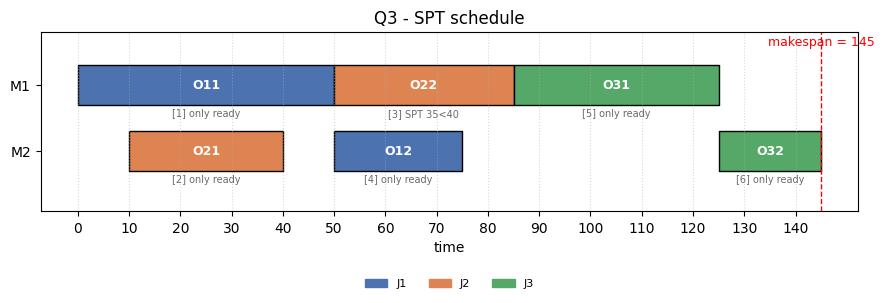

SPT makespan = 145 -> saved gantt_q3.png
caption key: [n] = decision order;  'SPT a<b' = chosen op's proc a beat competitor b


In [49]:
fig, spt_makespan = gantt(spt_results, title="Q3 - SPT schedule", save_as="gantt_q3.png", log=spt_log)
plt.show()
print("SPT makespan =", spt_makespan, "-> saved gantt_q3.png")
print("caption key: [n] = decision order;  'SPT a<b' = chosen op's proc a beat competitor b")

## Step 9 - Q4: completion times for SPT + compare makespans

Reuses `completion_times()` from Step 6 on the SPT schedule (`spt_results`), then puts the SPT and
FCFS makespans side by side to decide which solution is better.

Needs Step 4 (`results` = FCFS) and Step 7 (`spt_results` = SPT) to have run first.

In [50]:
# SPT completion times (reuse the Step 6 helper on the SPT schedule)
spt_comp, spt_last = completion_times(spt_results)
fcfs_comp, _ = completion_times(results)          # results = FCFS schedule from Step 4

spt_makespan = max(spt_comp.values())
fcfs_makespan = max(fcfs_comp.values())

print("SPT - completion time of each job (finish of its last operation):\n")
for job in sorted(spt_comp):
    print(f"  C({job}) = {spt_comp[job]:>3}   (last operation: {spt_last[job]})")
print(f"\nSPT makespan = max({', '.join(str(spt_comp[j]) for j in sorted(spt_comp))}) = {spt_makespan}")

# side-by-side comparison with FCFS (Q1/Q2)
print("\n" + "=" * 60)
print("Comparison: FCFS (Q1) vs SPT (Q3)")
print("=" * 60)
print(f"{'Job':<10}{'FCFS Cj':>10}{'SPT Cj':>10}")
for job in sorted(spt_comp):
    print(f"{job:<10}{fcfs_comp[job]:>10}{spt_comp[job]:>10}")
print(f"{'Makespan':<10}{fcfs_makespan:>10}{spt_makespan:>10}")

# the conclusion
print("\n" + "-" * 60)
if fcfs_makespan != spt_makespan:
    if fcfs_makespan < spt_makespan:
        better, bm, worse, wm = "FCFS", fcfs_makespan, "SPT", spt_makespan
    else:
        better, bm, worse, wm = "SPT", spt_makespan, "FCFS", fcfs_makespan
    print(f"=> {better} is better for THIS instance: makespan {bm} < {wm} (shorter by {wm - bm}).")
else:
    print(f"=> Tie: both makespans = {fcfs_makespan}.")
print("-" * 60)
print("\nREPORT NOTE (Q4): the 'smarter-looking' SPT rule is actually WORSE here.")
print("This is the hook for Q5 - one good result does not make a rule better.")

SPT - completion time of each job (finish of its last operation):

  C(J1) =  75   (last operation: O12)
  C(J2) =  85   (last operation: O22)
  C(J3) = 145   (last operation: O32)

SPT makespan = max(75, 85, 145) = 145

Comparison: FCFS (Q1) vs SPT (Q3)
Job          FCFS Cj    SPT Cj
J1                75        75
J2               125        85
J3               110       145
Makespan         125       145

------------------------------------------------------------
=> FCFS is better for THIS instance: makespan 125 < 145 (shorter by 20).
------------------------------------------------------------

REPORT NOTE (Q4): the 'smarter-looking' SPT rule is actually WORSE here.
This is the hook for Q5 - one good result does not make a rule better.
